In [42]:
from ucimlrepo import fetch_ucirepo 
from scipy.stats import boxcox
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import pandas as pd
import shutil
import seaborn as sns
import numpy as np


# Fetch dataset 
support2 = fetch_ucirepo(id=880) 

# Data (as pandas dataframes) 
X = support2.data.features 
y = support2.data.targets 

# Combine features and targets into a single DataFrame, if desired
df = pd.concat([X, y], axis=1)

# # Save to CSV
# df.to_csv('output.csv', index=False)

# # Move the file to a location where it can be accessed/downloaded
# shutil.move('output.csv', 'csv')

# metadata 
print(support2.metadata) 

# variable information 
print(support2.variables)

# Remove non-numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Handle missing values
numeric_df = numeric_df.fillna(numeric_df.mean())



{'uci_id': 880, 'name': 'SUPPORT2', 'repository_url': 'https://archive.ics.uci.edu/dataset/880/support2', 'data_url': 'https://archive.ics.uci.edu/static/public/880/data.csv', 'abstract': "This dataset comprises 9105 individual critically ill patients across 5 United States medical centers, accessioned throughout 1989-1991 and 1992-1994.\nEach row concerns hospitalized patient records who met the inclusion and exclusion criteria for nine disease categories: acute respiratory failure, chronic obstructive pulmonary disease, congestive heart failure, liver disease, coma, colon cancer, lung cancer, multiple organ system failure with malignancy, and multiple organ system failure with sepsis. The goal is to determine these patients' 2- and 6-month survival rates based on several physiologic, demographics, and disease severity information. \nIt is an important problem because it addresses the growing national concern over patients' loss of control near the end of life. It enables earlier deci

In [28]:
df = pd.read_csv('data.csv', header = None)
df.columns = ['id','age','death','sex','hospdead','slos','d.time','dzgroup','dzclass','num.co','edu','income','scoma','charges','totcst','totmcst','avtisst','race','sps','aps','surv2m','surv6m','hday','diabetes','dementia','ca','prg2m','prg6m','dnr','dnrday','meanbp','wblc','hrt','resp','temp','pafi','alb','bili','crea','sod','ph','glucose','bun','urine','adlp','adls','sfdm2','adlsc']
df.head()

,id,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,...,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
0,id,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,...,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
1,1,62.84998,0,male,0,5,2029,Lung Cancer,Cancer,0,...,1.19995117,141,7.459961,NaN,NaN,NaN,7,7,NaN,7
2,2,60.33899,1,female,1,4,4,Cirrhosis,COPD/CHF/Cirrhosis,2,...,5.5,132,7.25,NaN,NaN,NaN,NaN,1,<2 mo. follow-up,1
3,3,52.74698,1,female,0,17,47,Cirrhosis,COPD/CHF/Cirrhosis,2,...,2,134,7.459961,NaN,NaN,NaN,1,0,<2 mo. follow-up,0
4,4,42.38498,1,female,0,3,133,Lung Cancer,Cancer,2,...,0.79992676,139,NaN,NaN,NaN,NaN,0,0,no(M2 and SIP pres),0


Target : Charges

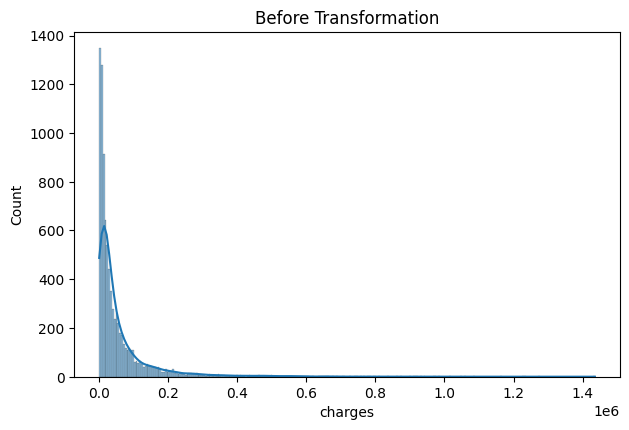

In [29]:
# กำหนด Target variable
target_variable = pd.to_numeric(df['charges'], errors='coerce')

# ดูการกระจายตัวของข้อมูลก่อนการแปลง
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
sns.histplot(target_variable, kde=True)
plt.title('Before Transformation')

plt.tight_layout()
plt.show()

Log Transformation method

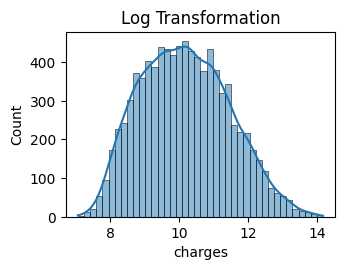

In [30]:

log_transformed = np.log1p(target_variable)  # ใช้ np.log1p เพื่อหลีกเลี่ยง log(0) ที่ไม่กำหนดค่า
plt.subplot(2, 2, 2)
sns.histplot(log_transformed, kde=True)
plt.title('Log Transformation')

plt.tight_layout()
plt.show()

Square root transformation

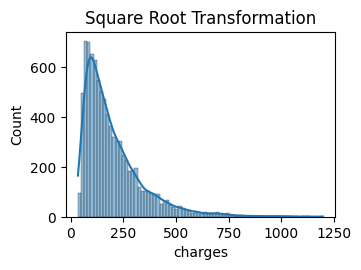

In [31]:
sqrt_transformed = np.sqrt(target_variable)
plt.subplot(2, 2, 3)
sns.histplot(sqrt_transformed, kde=True)
plt.title('Square Root Transformation')

plt.tight_layout()
plt.show()

Box-Cox Transformation

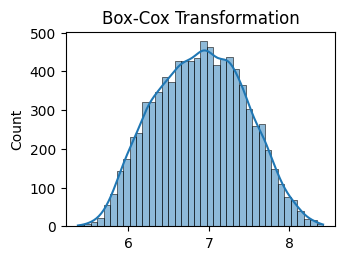

In [32]:
target_variable = target_variable.dropna()
target_variable = target_variable[target_variable > 0]

target_variable_positive = target_variable + 0.001
boxcox_transformed, _ = boxcox(target_variable_positive)
plt.subplot(2, 2, 4)
sns.histplot(boxcox_transformed, kde=True)
plt.title('Box-Cox Transformation')

plt.tight_layout()
plt.show()

Normalization Min-Max

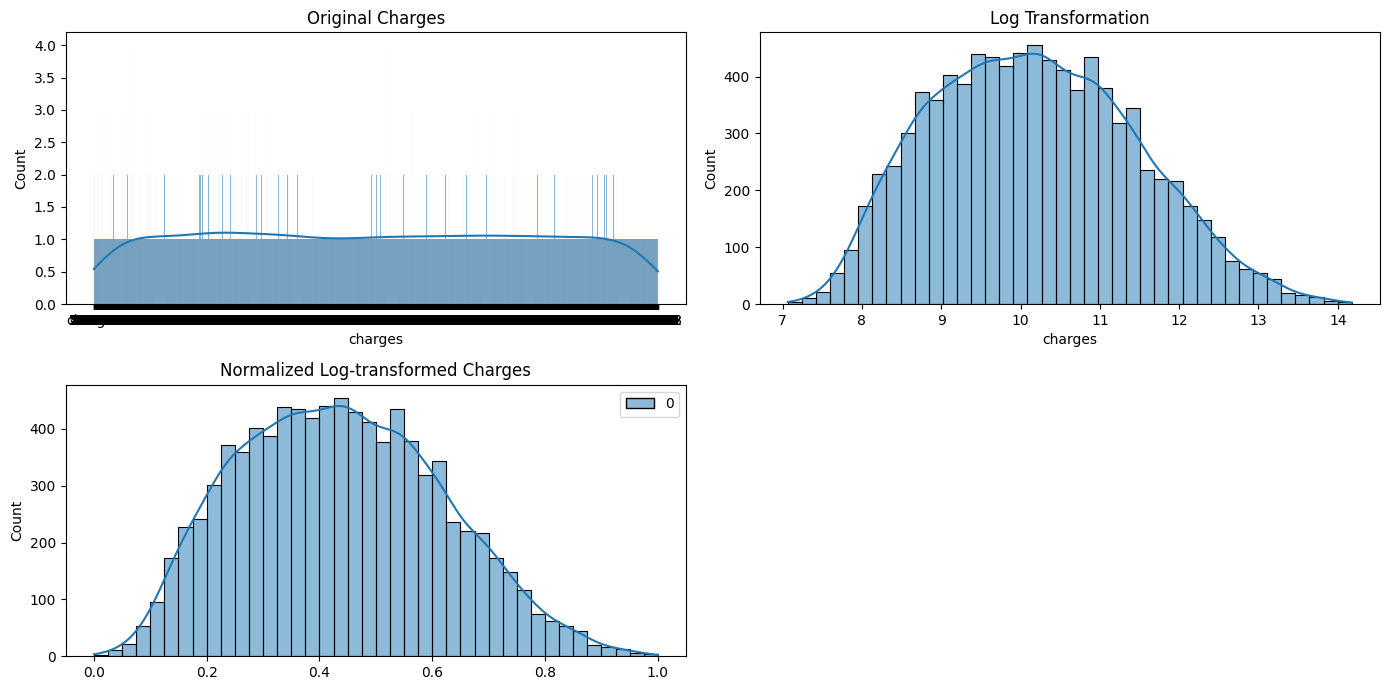

In [33]:
# Normalize the log-transformed values
scaler = MinMaxScaler()
log_transformed_normalized = scaler.fit_transform(log_transformed.values.reshape(-1, 1))

# Add normalized log-transformed charges to the dataframe
df['log_transformed_normalized'] = log_transformed_normalized

# Plot
plt.figure(figsize=(14, 7))

plt.subplot(2, 2, 1)
sns.histplot(df['charges'], kde=True)
plt.title('Original Charges')

plt.subplot(2, 2, 2)
sns.histplot(log_transformed, kde=True)
plt.title('Log Transformation')

plt.subplot(2, 2, 3)
sns.histplot(log_transformed_normalized, kde=True)
plt.title('Normalized Log-transformed Charges')

plt.tight_layout()
plt.show()

Feature Selection
1. Filter Method (Correlation Matrix)

In [40]:
# Compute the correlation matrix
correlation_matrix = numeric_df.corr()

# Compute correlation with the target variable
target_correlation = correlation_matrix['charges'].abs().sort_values(ascending=False)

# # Select features with high correlation with the target variable
# high_correlation_features = target_correlation[target_correlation > 0.1].index
# print(high_correlation_features)

KeyError: 'charges'